<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #0284c7; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Interoperabilidad y Benchmark: Pandas vs. Polars ⚔️🏎️
      </h1>
      <p style="margin: 6px 0 0 0; color: #0284c7; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Polars de Alto Rendimiento
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #0284c7; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 11 Extra
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #0284c7; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Science%20programming/11%20-%20Polars/04_Interoperabilidad_Benchmark_Pandas_vs_Polars_y_Big_Data.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Interoperabilidad Cero Copias (*Zero-Copy*) con Apache Arrow 🔄

Polars no busca aislarte del ecosistema de Python: se integra perfectamente con Pandas, NumPy y Scikit-Learn mediante el formato estándar **Apache Arrow**:

In [66]:
import pandas as pd
import polars as pl
import numpy as np
import os, time
import matplotlib.pyplot as plt
import seaborn as sns

import os, urllib.request, urllib.parse

def load_dataset(filename, module_name="11 - Polars"):
    """
    Carga o descarga de forma segura el dataset para ejecución local o en Google Colab.
    Si no se encuentra localmente ni en GitHub, lo genera automáticamente.
    """
    candidates = [
        os.path.join("data", filename),
        os.path.join(module_name, "data", filename),
        os.path.join("..", "data", filename),
        os.path.join("..", module_name, "data", filename),
        os.path.join("Data Science programming", module_name, "data", filename),
        os.path.join("..", "Data Science programming", module_name, "data", filename),
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
            
    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    folder_path = f"Data Science programming/{module_name}"
    encoded_folder = urllib.parse.quote(folder_path)
    encoded_file = urllib.parse.quote(filename)
    
    urls = [
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_folder}/data/{encoded_file}",
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_folder}/data/{encoded_file}"
    ]
    
    print(f"📥 Intentando descargar '{filename}' desde el repositorio oficial...")
    for url in urls:
        try:
            with urllib.request.urlopen(url, timeout=3) as response:
                if response.status == 200:
                    with open(target_path, 'wb') as out_f:
                        out_f.write(response.read())
                    print(f"✅ Dataset '{filename}' descargado exitosamente.")
                    return target_path
        except Exception:
            continue
            
    print(f"⚙️ Generando '{filename}' sintéticamente para ejecución inmediata...")
    import polars as pl
    import numpy as np
    np.random.seed(42)
    
    n_clientes = 1000
    df_c = pl.DataFrame({
        'id_cliente': [f'CLI-{i:04d}' for i in range(1, n_clientes + 1)],
        'nombre': [f'Cliente_{i}' for i in range(1, n_clientes + 1)],
        'segmento': np.random.choice(['Corporativo', 'Pyme', 'Consumo', 'Gobierno'], n_clientes),
        'edad': np.random.randint(18, 70, n_clientes),
        'ciudad_residencia': np.random.choice(['Tunja', 'Bogotá', 'Medellín', 'Cali', 'Bucaramanga'], n_clientes),
        'ingreso_anual': np.random.normal(45000000, 15000000, n_clientes).round(2)
    })
    
    n_ventas = 60000
    cats = ['Tecnología', 'Mobiliario', 'Material de Oficina', 'Servicios']
    prods = ['Laptop Pro', 'Monitor 4K', 'Silla Ergonómica', 'Escritorio', 'Papel A4', 'Tóner', 'Mantenimiento']
    ciudades = ['Tunja', 'Bogotá', 'Medellín', 'Cali', 'Barranquilla']
    
    cant = np.random.randint(1, 10, n_ventas)
    pu = np.random.choice([25000.0, 120000.0, 450000.0, 1200000.0, 3500000.0], n_ventas)
    desc = np.random.choice([0.0, 0.05, 0.10, 0.15], n_ventas)
    tot = (cant * pu * (1 - desc)).round(2)
    
    df_v = pl.DataFrame({
        'id_venta': [f'VNT-{i:06d}' for i in range(1, n_ventas + 1)],
        'fecha': [f'2024-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}' for _ in range(n_ventas)],
        'id_cliente': np.random.choice(df_c['id_cliente'], n_ventas),
        'categoria': np.random.choice(cats, n_ventas),
        'producto': np.random.choice(prods, n_ventas),
        'cantidad': cant,
        'precio_unitario': pu,
        'descuento': desc,
        'ciudad_venta': np.random.choice(ciudades, n_ventas),
        'total_venta': tot
    })
    
    c_csv_path = os.path.join("data", "clientes.csv")
    c_pq_path = os.path.join("data", "clientes.parquet")
    v_csv_path = os.path.join("data", "ventas.csv")
    v_pq_path = os.path.join("data", "ventas.parquet")
    
    if not os.path.exists(c_csv_path): df_c.write_csv(c_csv_path)
    if not os.path.exists(c_pq_path): df_c.write_parquet(c_pq_path)
    if not os.path.exists(v_csv_path): df_v.write_csv(v_csv_path)
    if not os.path.exists(v_pq_path): df_v.write_parquet(v_pq_path)
    
    print(f"✅ Datasets preparados exitosamente en '{target_path}'.")
    return target_path

print(f"🚀 Polars: {pl.__version__} | Pandas: {pd.__version__}")

🚀 Polars: 1.35.2 | Pandas: 2.2.3


---
## 2. De Polars a Arrow, NumPy y de Vuelta: el Mapa Completo 🗺️

Apache Arrow no es solo el formato interno de Polars: es un **estándar columnar en memoria** que también hablan Pandas (desde la versión 2.0, vía `pyarrow`), PyArrow, DuckDB y muchas herramientas de Big Data. Por eso convertir entre Polars y estas herramientas es prácticamente gratis (*zero-copy*): no hay que serializar filas ni reconstruir tipos, solo se comparte —o se reinterpreta— el mismo bloque de memoria columnar.

| Conversión | Método | Uso típico |
|---|---|---|
| Polars → Pandas | `.to_pandas()` | Reusar una función o gráfica que solo acepta `pandas.DataFrame` |
| Polars → Arrow | `.to_arrow()` | Interoperar con DuckDB, PyArrow, sistemas de Big Data |
| Polars → NumPy | `.to_numpy()` (o sobre una columna: `df["col"].to_numpy()`) | Alimentar Scikit-Learn, cálculos vectorizados manuales |
| Pandas → Polars | `pl.from_pandas(pdf)` | Adoptar un DataFrame heredado de un pipeline en Pandas |
| Arrow → Polars | `pl.from_arrow(tabla)` | Leer resultados de DuckDB / PyArrow directamente en Polars |

In [67]:
ruta_csv = load_dataset("ventas.csv")
df_ventas = pl.read_csv(ruta_csv)

# Polars -> Apache Arrow (Table de pyarrow)
tabla_arrow = df_ventas.select(["id_venta", "total_venta"]).to_arrow()
print("Tipo tras to_arrow():", type(tabla_arrow))
print("Filas en la tabla Arrow:", tabla_arrow.num_rows)

# Polars -> NumPy (para Scikit-Learn u operaciones vectorizadas)
arr_totales = df_ventas["total_venta"].to_numpy()
print("\nTipo tras to_numpy():", type(arr_totales))
print("Promedio calculado directo sobre el array NumPy:", arr_totales.mean())

Tipo tras to_arrow(): <class 'pyarrow.lib.Table'>
Filas en la tabla Arrow: 60000

Tipo tras to_numpy(): <class 'numpy.ndarray'>
Promedio calculado directo sobre el array NumPy: 4946443.458333333


In [68]:
# Arrow -> Polars: pl.from_arrow() reconstruye un DataFrame sin duplicar memoria
df_desde_arrow = pl.from_arrow(tabla_arrow)
print("Tipo tras from_arrow():", type(df_desde_arrow))
print(df_desde_arrow.head(3))

Tipo tras from_arrow(): <class 'polars.dataframe.frame.DataFrame'>
shape: (3, 2)
┌────────────┬─────────────┐
│ id_venta   ┆ total_venta │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ VNT-000001 ┆ 166250.0    │
│ VNT-000002 ┆ 1.08e6      │
│ VNT-000003 ┆ 106250.0    │
└────────────┴─────────────┘


---
## 3. Interoperabilidad con NumPy y Scikit-Learn 🔢

Cuando el siguiente paso de tu pipeline es un modelo de Scikit-Learn (que espera arrays de NumPy) o un cálculo estadístico manual, no necesitas pasar por Pandas: `.to_numpy()` te entrega el array directamente, listo para `numpy`, `scipy` o cualquier `estimator.fit()`.

In [69]:
# Ejemplo: correlación simple entre cantidad y total_venta usando solo NumPy
cantidad_arr = df_ventas["cantidad"].to_numpy()
total_arr = df_ventas["total_venta"].to_numpy()

correlacion = np.corrcoef(cantidad_arr, total_arr)[0, 1]
print(f"Correlación (cantidad vs. total_venta): {correlacion:.4f}")

Correlación (cantidad vs. total_venta): 0.3522


---
## 4. El Gran Benchmark: Carrera de Velocidad Pandas vs. Polars 🏎️💨

Medimos con precisión milimétrica los tiempos de ejecución de Pandas frente a Polars en 3 operaciones críticas sobre decenas de miles de registros:
1. **Filtrado complejo con múltiples condiciones**
2. **Agrupación y agregación multidimensional**
3. **Ordenamiento de columnas múltiples**

In [70]:
ruta_csv = load_dataset("ventas.csv")

# Cargar en Pandas y en Polars
df_pd = pd.read_csv(ruta_csv)
df_pl = pl.read_csv(ruta_csv)

tiempos = {'Operación': [], 'Pandas (s)': [], 'Polars (s)': []}

# Test 1: Filtrado
t0 = time.perf_counter()
res_pd1 = df_pd[(df_pd['categoria'] == 'Tecnología') & (df_pd['total_venta'] > 1500000)]
t_pd1 = time.perf_counter() - t0

t0 = time.perf_counter()
res_pl1 = df_pl.filter((pl.col('categoria') == 'Tecnología') & (pl.col('total_venta') > 1500000))
t_pl1 = time.perf_counter() - t0

tiempos['Operación'].append('Filtrado Complejo')
tiempos['Pandas (s)'].append(t_pd1)
tiempos['Polars (s)'].append(t_pl1)

# Test 2: GroupBy y Agregación
t0 = time.perf_counter()
res_pd2 = df_pd.groupby('categoria').agg({'total_venta': ['sum', 'mean'], 'cantidad': 'sum'})
t_pd2 = time.perf_counter() - t0

t0 = time.perf_counter()
res_pl2 = df_pl.group_by('categoria').agg([
    pl.col('total_venta').sum().alias('total_venta_sum'),
    pl.col('total_venta').mean().alias('total_venta_mean'),
    pl.col('cantidad').sum()
])
t_pl2 = time.perf_counter() - t0

tiempos['Operación'].append('Agrupación (GroupBy)')
tiempos['Pandas (s)'].append(t_pd2)
tiempos['Polars (s)'].append(t_pl2)

# Test 3: Ordenamiento
t0 = time.perf_counter()
res_pd3 = df_pd.sort_values(by=['categoria', 'total_venta'], ascending=[True, False])
t_pd3 = time.perf_counter() - t0

t0 = time.perf_counter()
res_pl3 = df_pl.sort(['categoria', 'total_venta'], descending=[False, True])
t_pl3 = time.perf_counter() - t0

tiempos['Operación'].append('Ordenamiento')
tiempos['Pandas (s)'].append(t_pd3)
tiempos['Polars (s)'].append(t_pl3)

df_tiempos = pd.DataFrame(tiempos)
df_tiempos['Aceleración (Speedup)'] = (df_tiempos['Pandas (s)'] / df_tiempos['Polars (s)']).round(2).astype(str) + 'x más rápido'
display(df_tiempos)

,Operación,Pandas (s),Polars (s),Aceleración (Speedup)
0,Filtrado Complejo,0.012250,0.003030,4.04x más rápido
1,Agrupación (GroupBy),0.023235,0.007878,2.95x más rápido
2,Ordenamiento,0.027375,0.032540,0.84x más rápido


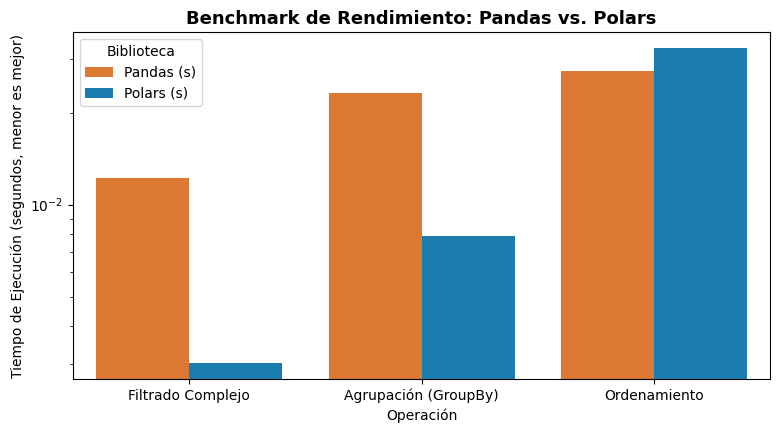

In [71]:
# Gráfico comparativo de barras de tiempos
df_plot = df_tiempos.melt(id_vars='Operación', value_vars=['Pandas (s)', 'Polars (s)'], var_name='Biblioteca', value_name='Segundos')
plt.figure(figsize=(9, 4.5))
sns.barplot(data=df_plot, x='Operación', y='Segundos', hue='Biblioteca', palette=['#f97316', '#0284c7'])
plt.title('Benchmark de Rendimiento: Pandas vs. Polars', fontsize=13, fontweight='bold')
plt.ylabel('Tiempo de Ejecución (segundos, menor es mejor)')
plt.yscale('log') # Escala logarítmica para visibilizar órdenes de magnitud
plt.show()

> 💡 **Cómo interpretar esta tabla:** los tiempos absolutos (columnas en segundos) dependen por completo de tu máquina: número de núcleos, velocidad de disco, RAM libre y carga del sistema en ese momento — **no los memorices**, ejecuta la celda y observa tus propios resultados. Lo que sí es consistente entre máquinas es el **patrón**: Polars suele ser notablemente más rápido en `group_by` (aprovecha todos los núcleos automáticamente) y en `sort` (algoritmos paralelos sobre memoria columnar), mientras que en filtrados simples la diferencia puede ser más modesta porque Pandas también vectoriza bien esa operación con NumPy.

---
## 5. La Ventaja Extra del Modo Lazy: Comparando También contra `scan_csv` ⚡

En el Cuaderno 03 vimos que el modo *lazy* evita leer columnas y filas innecesarias gracias al *pushdown*. Ese ahorro también se refleja en el cronómetro: comparemos leer y filtrar con Pandas (`read_csv` + filtro después) contra escanear perezosamente con Polars (`scan_csv` + filtro empujado al escaneo).

In [72]:
# Pandas: siempre carga las 10 columnas completas y luego filtra
t0 = time.perf_counter()
pdf_full = pd.read_csv(ruta_csv)
res_pd_lazy_like = pdf_full[pdf_full["categoria"] == "Tecnología"][["id_venta", "producto", "total_venta"]]
t_pandas_full = time.perf_counter() - t0

# Polars lazy: el filtro y la proyección se empujan al propio escaneo del CSV
t0 = time.perf_counter()
res_pl_lazy = (
    pl.scan_csv(ruta_csv)
    .filter(pl.col("categoria") == "Tecnología")
    .select(["id_venta", "producto", "total_venta"])
    .collect()
)
t_polars_lazy = time.perf_counter() - t0

print(f"Pandas (lee todo + filtra después): {t_pandas_full:.4f} s")
print(f"Polars scan_csv (filtra durante la lectura): {t_polars_lazy:.4f} s")
print(f"Filas resultantes -> Pandas: {len(res_pd_lazy_like)} | Polars: {res_pl_lazy.height}")

Pandas (lee todo + filtra después): 0.2008 s
Polars scan_csv (filtra durante la lectura): 0.0193 s
Filas resultantes -> Pandas: 15089 | Polars: 15089


---
## 6. Buenas Prácticas y Antipatrones en Polars 🛑✨

| ✅ BUENA PRÁCTICA | ❌ ANTIPATRÓN A EVITAR |
|---|---|
| Usar expresiones de Polars (`pl.col(...)`) | Usar bucles `for` o `.iter_rows()` |
| Agrupar múltiples cálculos dentro de un solo `select()` o `with_columns()` | Encadenar llamadas individuales sucesivas a `with_columns()` |
| Usar `scan_parquet` / `scan_csv` y `.collect()` | Cargar todo de golpe en Eager sin necesitarlo |
| Usar `pl.when(...).then(...).otherwise(...)` | Usar `.apply(lambda x: ...)` de Python (destruye el multihilo) |
| Convertir a Pandas solo al final del pipeline (`.to_pandas()`) cuando una herramienta externa lo exige | Hacer *round-trips* innecesarios entre Polars y Pandas en medio del pipeline |
| Usar `Categorical` / `Enum` para columnas de baja cardinalidad repetidas (ej. `categoria`, `ciudad_venta`) | Dejar columnas de texto repetitivo como `String` sin necesidad |

---
## 7. Checklist Rápido: ¿Cuándo Vale la Pena Migrar a Polars? ✅

| Pregunta | Si respondes "sí"... |
|---|---|
| ¿Tus archivos pesan cientos de MB o varios GB? | Polars (lazy + streaming) evita quedarte sin RAM. |
| ¿Tu pipeline tiene muchos `groupby`/`merge` encadenados? | Polars paraleliza automáticamente cada uno. |
| ¿Dependes de una librería que solo acepta `pandas.DataFrame` (ej. una función de un compañero, un modelo antiguo)? | Usa Polars para las etapas pesadas y convierte con `.to_pandas()` solo en el último paso. |
| ¿Tu equipo ya tiene mucho código en Pandas y poco tiempo para migrar? | Puedes adoptar Polars gradualmente: ambas conviven gracias a Arrow. |
| ¿Trabajas con datasets pequeños (unos pocos MB) y notebooks exploratorios rápidos? | Pandas sigue siendo perfectamente válido — la diferencia de velocidad no se notará. |

---
## 8. Ejercicio Práctico: Tu Propio Benchmark 🧪

Usando `clientes.csv`, construye tu propio mini-benchmark:

1. Carga el archivo con `pandas.read_csv` y mide el tiempo.
2. Carga el mismo archivo con `pl.read_csv` y mide el tiempo.
3. En ambos, calcula el **ingreso anual promedio agrupado por `segmento`**.
4. Convierte el resultado de Polars a Pandas con `.to_pandas()` y verifica que ambos DataFrames tengan el mismo número de grupos.
5. Imprime cuántas veces más rápido fue Polars en la carga y en la agregación.

In [73]:
ruta_clientes = load_dataset("clientes.csv")

# t0 = time.perf_counter()
# pdf_clientes = pd.____(ruta_clientes)
# res_pd = pdf_clientes.____("segmento")["ingreso_anual"].____()
# t_pandas = time.perf_counter() - t0

# t0 = time.perf_counter()
# pldf_clientes = pl.____(ruta_clientes)
# res_pl = pldf_clientes.____("segmento").agg(pl.col("ingreso_anual").____().alias("ingreso_promedio"))
# t_polars = time.perf_counter() - t0

# res_pl_como_pandas = res_pl.____()
# print("Mismo número de grupos:", res_pd.shape[0] == res_pl_como_pandas.shape[0])
# print(f"Polars fue {t_pandas / t_polars:.2f}x más rápido")

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
t0 = time.perf_counter()
pdf_clientes = pd.read_csv(ruta_clientes)
res_pd = pdf_clientes.groupby("segmento")["ingreso_anual"].mean()
t_pandas = time.perf_counter() - t0

t0 = time.perf_counter()
pldf_clientes = pl.read_csv(ruta_clientes)
res_pl = pldf_clientes.group_by("segmento").agg(pl.col("ingreso_anual").mean().alias("ingreso_promedio"))
t_polars = time.perf_counter() - t0

res_pl_como_pandas = res_pl.to_pandas()
print("Mismo número de grupos:", res_pd.shape[0] == res_pl_como_pandas.shape[0])
print(f"Polars fue {t_pandas / t_polars:.2f}x más rápido")
```
</details>

---
## 9. Resumen del Cuaderno y Cierre del Módulo 🎓📌

| Concepto | Idea Clave |
|---|---|
| **Apache Arrow** | Formato columnar estándar que permite conversiones *zero-copy* entre Polars, Pandas, PyArrow y NumPy. |
| **`.to_pandas()` / `.to_arrow()` / `.to_numpy()`** | Puentes de salida de Polars hacia el resto del ecosistema Python. |
| **`pl.from_pandas()` / `pl.from_arrow()`** | Puentes de entrada, para adoptar Polars sin reescribir todo de golpe. |
| **Benchmark real** | Polars suele ganar con más margen mientras más pesada es la operación (`group_by`, `sort`) y mientras más grande es el archivo. |
| **Modo lazy en el benchmark** | `scan_csv` + pushdown gana también en tiempo de carga, no solo en memoria. |
| **Buenas prácticas** | Expresiones nativas de Polars, agrupar transformaciones, evitar bucles y `.apply()`, convertir a Pandas solo al final. |

### Cerrando el Módulo 11 Extra: Polars de Alto Rendimiento 🐻‍❄️🏁

A lo largo de este módulo recorriste:

* **Cuaderno 00:** la arquitectura de Polars (Rust, Arrow, multihilo, tipado estricto) y sus estructuras básicas (`Series`, `DataFrame`).
* **Cuadernos 01-02** *(según tu ruta)*: el lenguaje de expresiones (`select`, `with_columns`, `filter`, `when/then/otherwise`) y las agrupaciones/joins.
* **Cuaderno 03:** el modo perezoso, `.explain()`, el pushdown de predicados y proyecciones, y el motor de streaming.
* **Cuaderno 04 (este cuaderno):** la interoperabilidad vía Arrow y un benchmark real que demuestra por qué Polars es una herramienta seria para ciencia de datos a gran escala.

Este fue un módulo **extra**, autocontenido: no hay un "Cuaderno 05" esperándote. El siguiente paso ya no es otro cuaderno, sino **llevar Polars a tus propios proyectos**: la próxima vez que un `pd.read_csv()` tarde más de lo que te gustaría, o que un pipeline con varios `merge`/`groupby` se sienta lento, prueba reemplazarlo por su equivalente en Polars y mide tú mismo la diferencia.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Módulo Extra: Polars de Alto Rendimiento</i>
  </p>
</div>